[████████████████████] 100% | Step 20/20 | P: 100.00 W
--- Simulation Complete ---


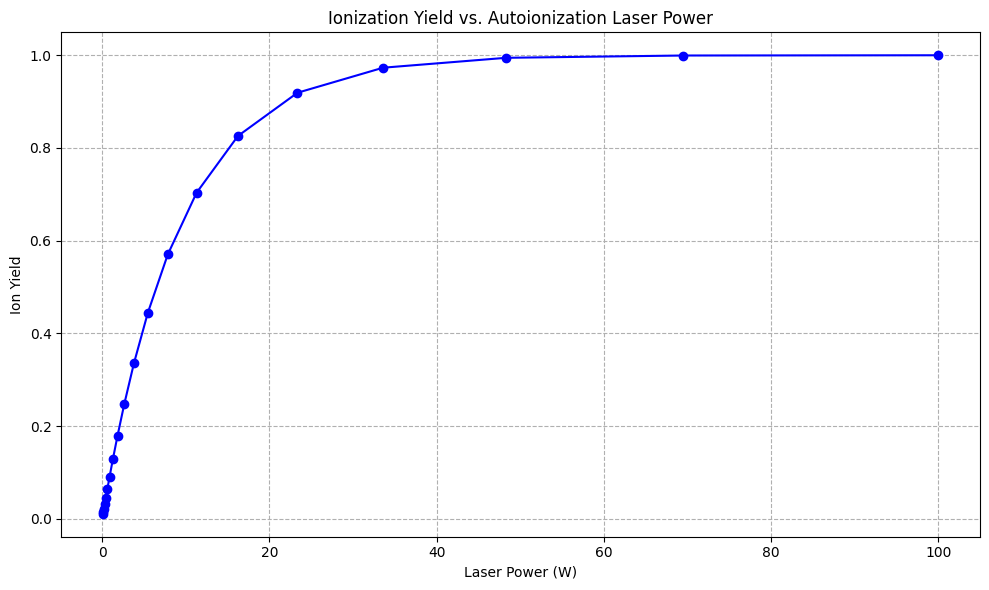

In [6]:
import densityMatrixSim as dm
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import scipy.constants as con
from multiprocessing import Pool

# Experimental Parameters
lambda_1 = 460.73330e-9 # From https://physics.nist.gov/PhysRefData/ASD/lines_form.html (Sr-I)
einstein461 = 2.01e8 # From NIST, [s^-1]
w_1 = 2*con.pi*con.c/lambda_1
I1 = 565.884 # 0.1W with 1.5cm spot size
mu461 = np.sqrt((3*con.pi*con.epsilon_0*con.hbar*einstein461*con.c**3)/(w_1**3))
rabi461 = (mu461/con.hbar)*np.sqrt((2*I1)/(con.c*con.epsilon_0))


lambda_2 = 405.16e-9 # From https://physics.nist.gov/PhysRefData/ASD/lines_form.html (Sr-I)
linewidth405 = 2*con.pi*45*con.c*100
w_2 = 2*con.pi*con.c/lambda_2
I2 = 5658.84 # 1W with 1.5cm diameter spot size
crossPeak = 5.6e-19 # Peak cross section in m^2
rabi405 = dm.calculate_rabi2(I2,w_2,crossPeak,linewidth405)
v_avg, t_int = dm.calculate_interaction_time(T_celsius=530.0, L_cm=1.5)
base_params = {
        'rabi_1': rabi461,
        'rabi_2': rabi405,
        'q': 6.8,
        'gamma_1': einstein461,
        'gamma_2': linewidth405,
        'del_ag': 0.0, 
        'del_bg': 0.0,
        'del_ba': 0.0,
    }

# run_time_dynamics(base_params, w_2, crossPeak, linewidth405)
dm.run_power_scaling(base_params, w_2, crossPeak, linewidth405, t_int)